In [1]:
## create structure
from pymatgen.core import Lattice, Structure, Molecule

In [2]:
coords = [[0, 0, 0], [0.75,0.5,0.75]]
lattice = Lattice.from_parameters(a=3.84, b=3.84, c=3.84, alpha=120,
                                  beta=90, gamma=60)
struct = Structure(lattice, ["Si", "Si"], coords)

In [3]:
struct

Structure Summary
Lattice
    abc : 3.84 3.8399999999999994 3.84
 angles : 119.99999999999999 90.0 60.00000000000001
 volume : 40.038580810231124
      A : 3.84 0.0 2.351321854362918e-16
      B : 1.92 2.7152900397563426 -1.919999999999999
      C : 0.0 0.0 3.84
    pbc : True True True
PeriodicSite: Si (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
PeriodicSite: Si (3.84, 1.358, 1.92) [0.75, 0.5, 0.75]

In [4]:
## try to generate x-ray diffraction pattern
from pymatgen.analysis.diffraction.xrd import XRDCalculator

In [6]:
xray_gen = XRDCalculator()

In [26]:
xray_dp = xray_gen.get_pattern(structure=struct, two_theta_range=(5, 150))

In [27]:
type(xray_dp)

pymatgen.analysis.diffraction.core.DiffractionPattern

In [28]:
dir(xray_dp)

['REDIRECT',
 'XLABEL',
 'YLABEL',
 '__add__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__div__',
 '__doc__',
 '__eq__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__get_pydantic_core_schema__',
 '__get_pydantic_json_schema__',
 '__get_validators__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__modify_schema__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_args',
 '_generic_json_schema',
 '_get_partial_json',
 '_kwargs',
 '_validate_monty',
 'as_dict',
 'copy',
 'd_hkls',
 'from_dict',
 'get_interpolated_value',
 'get_partial_json',
 'hkls',
 'load',
 'normalize',
 'save',
 'smear',
 'to_json',
 'unsafe_hash',
 'validate_monty_v1',
 'validate_monty_v2',
 'x',
 'y',
 'ydim']

In [29]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

<BarContainer object of 11 artists>

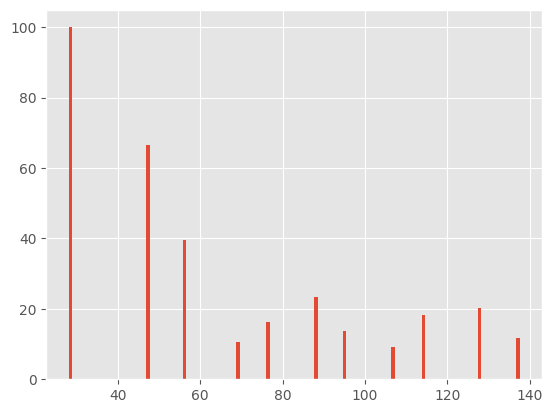

In [30]:
plt.bar(xray_dp.x, xray_dp.y)

In [31]:
xray_dp.x

array([ 28.46772426,  47.34657519,  56.17571327,  69.19895076,
        76.45494946,  88.1268895 ,  95.06167987, 106.84309944,
       114.24668324, 127.74800845, 137.14725104])

In [32]:
## generate for tem
from pymatgen.analysis.diffraction.tem import TEMCalculator

In [45]:
tem = TEMCalculator(camera_length=100, beam_direction=[1,1,1])

In [46]:
tem.get_plot_2d(structure=struct)